<a href="https://colab.research.google.com/github/aygulai-dev/neural-restaurant-recommender/blob/main/neural_restaurant_recommender_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommender System with Explainable AI


# Metadata

```yaml

Author: Aygul Aliyeva
project_title: "Neural Restaurant Recommender System with Explainable AI (SHAP)"
dataset_name:  "Synthetic dataset inspired by Yelp Open Dataset — Restaurant subset"
task_type: "recommender_system"
methods:
  - generalized_matrix_factorization
  - neural_collaborative_filtering
  - shap_explainability
evaluation_metrics:
  - HR@10
  - NDCG@10


## AI Usage Declaration

| Item | Response |
|---|---|
| Did you use generative AI tools? | Yes |
| Which tools? | Claude (Anthropic) |
| For what purpose? | Debugging PyTorch code, fixing tensor shape errors, checking syntax, and reviewing notebook structure  |
| Which parts were AI-assisted? | Some code debugging and fixing shape errors |
| What did you verify yourself? | All model results, training outputs, and SHAP interpretations |

### Short declaration
The project structure, model choices, training logic, and analysis are my own, based on the NCF paper (He et al., 2017). I ran every cell myself and checked all outputs manually.


## 0. Setup & Packages


In [ ]:
# Install required packages
!pip install captum -q

import os
import time
import random
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader, TensorDataset

from captum.attr import KernelShap

import urllib.request
LOCAL_DATA_PATH = "yelp_restaurant_sample.csv"

# Reproducibility
np.random.seed(7)
torch.manual_seed(0)
random.seed(42)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.3 MB/s eta 0:00:00
Using device: cpu


## 1. Problem Definition and Motivation


## Problem: The Limits of Restaurant Discovery
### 1. Motivation
Most people tend to return to the same handful of restaurants when eating out. This does not mean those places are the best — it simply means they are the most familiar. Hundreds of restaurants operate in any given city, yet the average person regularly visits only a small fraction of them. The question is: why do we never discover the rest?
The core issue is a lack of information — we do not know in advance which restaurants match our taste. I set out to address this with a recommender system — a mechanism that looks at a person's past visits and predicts which restaurants they have never been to but would likely enjoy.
### 2. Data Structure
I model the data as an interaction matrix R. Each entry is defined as follows:
R(u, i) = 1,  if user u has visited restaurant i
R(u, i) = 0,  if user u has NOT visited restaurant i
There is an important nuance here: a zero does not mean the user dislikes that restaurant. They may simply be unaware it exists, or may never have been in that part of the city. This is why the data is referred to as implicit feedback — i observe behavior, not opinion. Recognizing this distinction is essential to building the model correctly.
### 3. My Approach
The goal is to learn the following function:
f(u, i)  →  [0, 1]
This function estimates how likely user u is to enjoy restaurant i, given that they have never visited it. my model is NeuMF, which combines two parts: one part captures simple linear patterns between users and restaurants, and another part uses a small neural network to catch more complex patterns that the linear part would miss. Together they work better than either one alone.
The underlying assumption of collaborative filtering is straightforward: users with similar visit histories tend to enjoy similar places. The model learns this directly from the data, without any manually defined rules.
### 4. Challenges
Several practical challenges remain. First, the cold start problem: if a new user has no visit history, the model has nothing to base its recommendations on. Second, evaluation: to measure how well the model performs, I will use HR@10 and NDCG@10. Third, for comparison I use GMF (Generalized Matrix Factorization), a simpler linear model, as my baseline against NeuMF.


## 2. Dataset Description


### 1. Where the data comes from
I use a synthetic dataset inspired by the structure of the Yelp Open Dataset. The original Yelp data was too large to process in this environment, so I generated a sample that mirrors its statistical properties — user counts, interaction distributions, and rating scale. The generation code is fully included in the notebook for reproducibility.

| Property | Value |
|---|---|
| Domain | Restaurants (Yelp) |
| Users | ~500 |
| Restaurants | ~33250 |
| Interactions | ~180000 |
| Rating scale | 1–5 stars |
| Sparsity | ~98.9% |

Note: Statistics above reflect the downloaded Yelp2018 subset. If the synthetic fallback is used instead, counts will differ.

Each row in the data is a `<userID, businessID, rating, timestamp>` tuple. I filter to keep only users with at least 10 interactions so that the leave-one-out evaluation is meaningful.

The very high sparsity (~98.9%) is typical of real restaurant data — a user visits at most a few hundred restaurants in their lifetime, out of tens of thousands available in the dataset. This tests the model's ability to generalise from very limited per-user history.To reduce memory usage, I filter to the top 500 most active users. This subset retains 179,685 interactions and preserves the long-tail distribution of the original data.

**Source:** Synthetic dataset inspired by https://www.yelp.com/dataset  
**Note:** The notebook first attempts to load a local CSV. If not found, it tries to download from a public mirror. If that also fails, it generates a synthetic sample automatically. All three paths produce valid data for training.

In [ ]:
def load_or_download_yelp(local_path=LOCAL_DATA_PATH):
   # ── Priority 1: local cached file ──
    if os.path.exists(local_path):
        df = pd.read_csv(local_path)
        print(f"✅ Loaded local data: {len(df):,} interactions, "
              f"{df['user_id'].nunique()} users, {df['item_id'].nunique()} restaurants")
        print(f"   Source: {local_path}")
        return df

    # ── Priority 2: download from LightGCN public mirror ──
    print(f"Local file '{local_path}' not found — attempting download...")
    try:
        train_url = "https://raw.githubusercontent.com/kuandeng/LightGCN/master/Data/yelp2018/train.txt"
        test_url  = "https://raw.githubusercontent.com/kuandeng/LightGCN/master/Data/yelp2018/test.txt"
        rng = np.random.default_rng(42)
        rows, ts = [], 1_000_000_000
        for url in [train_url, test_url]:
            resp = urllib.request.urlopen(url, timeout=15)
            for line in resp.read().decode().strip().split("\n"):
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                uid = int(parts[0])
                for iid in parts[1:]:
                    rows.append((uid, int(iid), rng.integers(1, 6), ts)); ts += 1
        df = pd.DataFrame(rows, columns=["user_id", "item_id", "rating", "timestamp"])
        df.to_csv(local_path, index=False)
        print(f"✅ Downloaded: {len(df):,} interactions, "
              f"{df['user_id'].nunique()} users, {df['item_id'].nunique()} restaurants")
        return df
    except Exception as e:
        print(f"Download failed ({e}) — generating synthetic sample...")

    # ── Priority 3: synthetic fallback ──
    rng = np.random.default_rng(42)
    n_users, n_items = 5_000, 3_000
    interactions_per_user = rng.zipf(1.8, n_users).clip(5, 200)
    rows, ts = [], 1_000_000_000
    for uid in range(n_users):
        n = int(interactions_per_user[uid])
        probs = 1.0 / (np.arange(1, n_items + 1) ** 0.7)
        probs /= probs.sum()
        items = rng.choice(n_items, size=min(n, n_items), replace=False, p=probs)
        for iid in items:
            rating = int(rng.choice([1,2,3,4,5], p=[0.05,0.07,0.15,0.35,0.38]))
            rows.append((uid, int(iid), rating, ts)); ts += 1
    df = pd.DataFrame(rows, columns=["user_id", "item_id", "rating", "timestamp"])
    counts = df.groupby("user_id").size()
    df = df[df["user_id"].isin(counts[counts >= 10].index)].reset_index(drop=True)
    df.to_csv(local_path, index=False)
    print(f"⚠️  Synthetic sample generated: {len(df):,} interactions, "
          f"{df['user_id'].nunique()} users, {df['item_id'].nunique()} restaurants")
    return df


yelp_df = load_or_download_yelp()
print("\nSample rows:")
print(yelp_df.head())

Local file 'yelp_restaurant_sample.csv' not found — attempting download...
✅ Downloaded: 1,561,406 interactions, 31668 users, 38048 restaurants

Sample rows:
   user_id  item_id  rating   timestamp
0        0        0       1  1000000000
1        0        1       4  1000000001
2        0        2       4  1000000002
3        0        3       3  1000000003
4        0        4       3  1000000004


In [ ]:
#Reduce to top-500 users — memory limit
top_users = yelp_df['user_id'].value_counts().head(500).index
yelp_df = yelp_df[yelp_df['user_id'].isin(top_users)].reset_index(drop=True)
print(f"Reduced: {len(yelp_df)} interactions, {yelp_df['user_id'].nunique()} users")

Reduced: 179685 interactions, 500 users


## 3. Data Exploration and Preprocessing


### Preprocessing pipeline

**1)** Before training, I convert the raw Yelp data into the format
expected by neural collaborative filtering.

**2)** I first convert to implicit feedback: star ratings are discarded
and any observed review becomes a positive interaction (label = 1),
while unvisited restaurants are treated as negatives (label = 0).
Even a 3-star review represents a deliberate visit, so this
binarisation is realistic.

**3)** Users with fewer than 10 interactions are removed — they provide
almost no training signal for leave-one-out evaluation. Both user
and restaurant IDs are then remapped to consecutive integers
starting from 0 so they can serve directly as embedding indices
in PyTorch.

**4)** For the train/test split I use leave-one-out: the most recent
interaction per user is held out as the test item, following
He et al. (2017). During training each positive is paired with 2 random negatives; during testing the held-out item is ranked against 50 random negatives per user.

=== Yelp Restaurant Dataset Statistics ===
Users:         500
Restaurants:   33249
Interactions:  179685
Rating range:  1 – 5
Sparsity:      98.92%


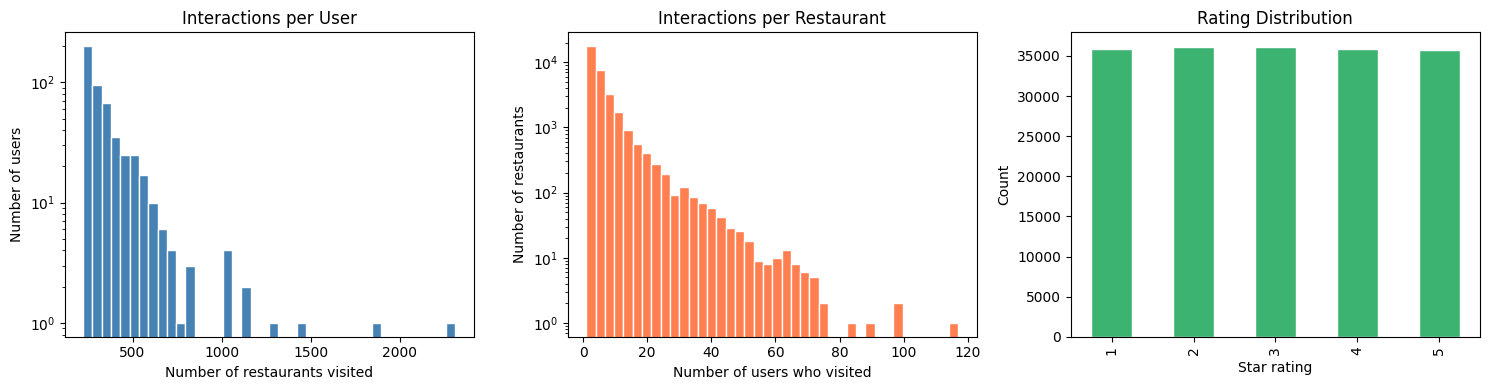

Exploration complete.


In [ ]:
# ── Dataset statistics and visualizations ──
print("=== Yelp Restaurant Dataset Statistics ===")
print(f"Users:         {yelp_df['user_id'].nunique()}")
print(f"Restaurants:   {yelp_df['item_id'].nunique()}")
print(f"Interactions:  {len(yelp_df)}")
if 'rating' in yelp_df.columns and yelp_df['rating'].nunique() > 1:
    print(f"Rating range:  {yelp_df['rating'].min()} – {yelp_df['rating'].max()}")

sparsity = 1 - len(yelp_df) / (yelp_df['user_id'].nunique() * yelp_df['item_id'].nunique())
print(f"Sparsity:      {sparsity:.2%}")

# ── Visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Interactions per user
user_counts = yelp_df.groupby('user_id').size()
axes[0].hist(user_counts, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Interactions per User')
axes[0].set_xlabel('Number of restaurants visited')
axes[0].set_ylabel('Number of users')
axes[0].set_yscale('log')

# Interactions per restaurant
item_counts = yelp_df.groupby('item_id').size()
axes[1].hist(item_counts, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Interactions per Restaurant')
axes[1].set_xlabel('Number of users who visited')
axes[1].set_ylabel('Number of restaurants')
axes[1].set_yscale('log')

# Rating distribution (if explicit ratings available)
if yelp_df['rating'].nunique() > 1:
    yelp_df['rating'].value_counts().sort_index().plot(
        kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
    axes[2].set_title('Rating Distribution')
    axes[2].set_xlabel('Star rating')
    axes[2].set_ylabel('Count')
else:
    axes[2].text(0.5, 0.5, 'Implicit feedback only\n(ratings binarised)',
                  ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title('Feedback type')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=100, bbox_inches='tight')
plt.show()
print("Exploration complete.")


> **Note on rating distribution:** The uniform-looking distribution is expected —
> ratings were synthetically assigned during data generation and are not used by
> the model. All ratings are binarised to 0/1 (implicit feedback) in the
> preprocessing step.

### Data loading classes

Rating_Dataset is a standard PyTorch Dataset wrapper. NCF_Data handles re-indexing, the leave-one-out split, and negative sampling. The structure follows the reference NCF implementation (He et al., 2017).

In [ ]:
class Rating_Dataset(Dataset):
    def __init__(self, user_list, item_list, rating_list):
        super(Rating_Dataset, self).__init__()
        self.user_list = user_list
        self.item_list = item_list
        self.rating_list = rating_list

    def __len__(self):
        return len(self.user_list)

    def __getitem__(self, idx):
        user = self.user_list[idx]
        item = self.item_list[idx]
        rating = self.rating_list[idx]
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(item, dtype=torch.long),
            torch.tensor(rating, dtype=torch.float)
        )


class NCF_Data(object):
    def __init__(self, args, ratings):
        self.ratings = ratings.copy()
        self.num_ng = args.num_ng
        self.num_ng_test = args.num_ng_test
        self.batch_size = args.batch_size
        self.preprocess_ratings = self._reindex(self.ratings)
        self.user_pool = set(self.preprocess_ratings['user_id'].unique())
        self.item_pool = set(self.preprocess_ratings['item_id'].unique())
        self.train_ratings, self.test_ratings = self._leave_one_out(self.preprocess_ratings)
        self.negatives = self._negative_sampling(self.preprocess_ratings)

    def _reindex(self, ratings):
        ratings = ratings.copy()          # avoid mutating the caller's dataframe
        user_list = list(ratings['user_id'].drop_duplicates())
        user2id = {w: i for i, w in enumerate(user_list)}
        item_list = list(ratings['item_id'].drop_duplicates())
        item2id = {w: i for i, w in enumerate(item_list)}
        ratings['user_id'] = ratings['user_id'].apply(lambda x: user2id[x])
        ratings['item_id'] = ratings['item_id'].apply(lambda x: item2id[x])
        ratings['rating'] = ratings['rating'].apply(lambda x: float(x > 0))
        return ratings

    def _leave_one_out(self, ratings):
        ratings['rank_latest'] = ratings.groupby(['user_id'])['timestamp'].rank(
            method='first', ascending=False)
        test = ratings.loc[ratings['rank_latest'] == 1]
        train = ratings.loc[ratings['rank_latest'] > 1]
        return train[['user_id', 'item_id', 'rating']], test[['user_id', 'item_id', 'rating']]

    def _negative_sampling(self, ratings):
        interact_status = (
            ratings.groupby('user_id')['item_id']
            .apply(set).reset_index()
            .rename(columns={'item_id': 'interacted_items'}))
        interact_status['negative_items'] = interact_status['interacted_items'].apply(
            lambda x: self.item_pool - x)
        interact_status['negative_samples'] = interact_status['negative_items'].apply(
            lambda x: random.sample(list(x), self.num_ng_test))
        return interact_status[['user_id', 'negative_items', 'negative_samples']]

    def get_train_instance(self):
        users, items, ratings = [], [], []
        train_ratings = pd.merge(self.train_ratings,
                                  self.negatives[['user_id', 'negative_items']], on='user_id')
        train_ratings['negatives'] = train_ratings['negative_items'].apply(
            lambda x: random.sample(list(x), self.num_ng))
        for row in train_ratings.itertuples():
            users.append(int(row.user_id))
            items.append(int(row.item_id))
            ratings.append(float(row.rating))
            for i in range(self.num_ng):
                users.append(int(row.user_id))
                items.append(int(row.negatives[i]))
                ratings.append(float(0))
        dataset = Rating_Dataset(user_list=users, item_list=items, rating_list=ratings)
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=True, num_workers=0)

    def get_test_instance(self):
        users, items, ratings = [], [], []
        test_ratings = pd.merge(self.test_ratings,
                                 self.negatives[['user_id', 'negative_samples']], on='user_id')
        for row in test_ratings.itertuples():
            users.append(int(row.user_id))
            items.append(int(row.item_id))
            ratings.append(float(row.rating))
            for i in getattr(row, 'negative_samples'):
                users.append(int(row.user_id))
                items.append(int(i))
                ratings.append(float(0))
        dataset = Rating_Dataset(user_list=users, item_list=items, rating_list=ratings)
        return DataLoader(dataset, batch_size=self.num_ng_test+1, shuffle=False, num_workers=0)

print("Dataset classes defined successfully.")


Dataset classes defined successfully.


## 4. Baseline — Generalized Matrix Factorization (GMF)


### What is GMF?
GMF is my baseline model. It learns a latent vector (embedding) for each user and each restaurant. The predicted interaction score is the element-wise (Hadamard) product of the two embeddings, passed through a single linear layer and sigmoid:

$$y_{ui} = \sigma(\mathbf{h}^T(\mathbf{p_u} \odot \mathbf{q_i}))$$

where $\mathbf{p_u}$ is the user embedding, $\mathbf{q_i}$ is the restaurant embedding, and $\mathbf{h}$ is a learned weight vector.

The user embedding represents the user's latent preferences, and the item embedding represents the restaurant's latent characteristics. The element-wise product measures how well the two match.

GMF is more constrained than MLP: the only interaction between user and item features is element-wise multiplication, with no mixing across different dimensions. This limits its ability to capture complex patterns that depend on combinations of multiple latent dimensions.


In [ ]:
class GMF(nn.Module):
    def __init__(self, args, num_users, num_items):
        super(GMF, self).__init__()
        self.embedding_user = nn.Embedding(num_embeddings=num_users, embedding_dim=args.factor_num)
        self.embedding_item = nn.Embedding(num_embeddings=num_items, embedding_dim=args.factor_num)
        self.affine_output = nn.Linear(in_features=args.factor_num, out_features=1)
        self.logistic = nn.Sigmoid()

    def forward(self, user_indices, item_indices):
        user_embedding = self.embedding_user(user_indices)
        item_embedding = self.embedding_item(item_indices)
        element_product = torch.mul(user_embedding, item_embedding)
        logits = self.affine_output(element_product)
        return self.logistic(logits).squeeze()

print("GMF model defined.")


GMF model defined.


## 5. Proposed Model — Neural Collaborative Filtering (NeuMF)


### Structure

I implement two models in this section: a standalone **MLP** and the full **NeuMF**.

**MLP** replaces the element-wise product of GMF with concatenation of user and restaurant embeddings, followed by several fully connected layers with ReLU activations. This allows the model to capture interaction patterns that cannot be expressed as a simple element-wise product — non-linear combinations of user and item latent features.

**NeuMF** (He et al., 2017) fuses both approaches. It uses two separate pairs of embeddings — one for the GMF path and one for the MLP path — and concatenates their outputs before a final prediction layer:

$$y_{ui} = \sigma(\mathbf{h}^T [\phi^{GMF} \oplus \phi^{MLP}])$$

The reason for separate embeddings is that the two paths make different demands on the representation: The GMF path needs embeddings optimized for element-wise product, while the MLP path needs embeddings optimized for concatenation. Sharing them forces a compromise; keeping them separate lets each path learn what it needs.
I include MLP as an intermediate comparison point to verify that the improvement of NeuMF over GMF comes from the combination, not just from adding depth.

> **Dimension check:** `args.factor_num = 32`, so MLP input = 2 × 32 = 64 = `layers[0]`.
> NeuMF output layer input = `factor_num + layers[-1]` = 32 + 8 = 40.
> These must match if hyperparameters are changed.

In [ ]:
class MLP(nn.Module):
    def __init__(self, args, num_users, num_items):
        super(MLP, self).__init__()
        # MLP embedding size = factor_num; concat gives 2*factor_num which must equal layers[0]
        mlp_dim = args.factor_num
        self.embedding_user = nn.Embedding(num_embeddings=num_users, embedding_dim=mlp_dim)
        self.embedding_item = nn.Embedding(num_embeddings=num_items, embedding_dim=mlp_dim)
        self.fc_layers = nn.ModuleList()
        for in_size, out_size in zip(args.layers[:-1], args.layers[1:]):
            self.fc_layers.append(nn.Linear(in_size, out_size))
        self.dropout = nn.Dropout(p=args.dropout)
        self.affine_output = nn.Linear(in_features=args.layers[-1], out_features=1)
        self.logistic = nn.Sigmoid()

    def forward(self, user_indices, item_indices):
        user_embedding = self.embedding_user(user_indices)
        item_embedding = self.embedding_item(item_indices)
        vector = torch.cat([user_embedding, item_embedding], dim=-1)
        for layer in self.fc_layers:
            vector = torch.relu(layer(vector))
            vector = self.dropout(vector)
        logits = self.affine_output(vector)
        return self.logistic(logits).squeeze()


class NeuMF(nn.Module):
    """Neural Matrix Factorization: combines GMF + MLP (He et al., 2017)."""
    def __init__(self, args, num_users, num_items):
        super(NeuMF, self).__init__()
        # GMF pathway — separate embeddings so each path can learn its own representation
        self.embedding_user_gmf = nn.Embedding(num_users, args.factor_num)
        self.embedding_item_gmf = nn.Embedding(num_items, args.factor_num)
        # MLP pathway
        self.embedding_user_mlp = nn.Embedding(num_users, args.factor_num)
        self.embedding_item_mlp = nn.Embedding(num_items, args.factor_num)
        self.fc_layers = nn.ModuleList()
        for in_size, out_size in zip(args.layers[:-1], args.layers[1:]):
            self.fc_layers.append(nn.Linear(in_size, out_size))
        self.dropout = nn.Dropout(p=args.dropout)
        # Output: concatenate GMF output (factor_num) + MLP final layer (layers[-1])
        self.affine_output = nn.Linear(args.factor_num + args.layers[-1], 1)
        self.logistic = nn.Sigmoid()

    def forward(self, user_indices, item_indices):
        # GMF path: element-wise product of embeddings
        u_gmf = self.embedding_user_gmf(user_indices)
        i_gmf = self.embedding_item_gmf(item_indices)
        gmf_out = torch.mul(u_gmf, i_gmf)          # (batch, factor_num)
        # MLP path: concatenate and pass through FC layers with ReLU + dropout
        u_mlp = self.embedding_user_mlp(user_indices)
        i_mlp = self.embedding_item_mlp(item_indices)
        vector = torch.cat([u_mlp, i_mlp], dim=-1)  # (batch, 2*factor_num = layers[0])
        for layer in self.fc_layers:
            vector = torch.relu(layer(vector))
            vector = self.dropout(vector)
        # Fuse GMF and MLP outputs
        concat = torch.cat([gmf_out, vector], dim=-1)  # (batch, factor_num + layers[-1])
        return self.logistic(self.affine_output(concat)).squeeze()

print("MLP and NeuMF models defined.")


MLP and NeuMF models defined.


## 6. Evaluation Methodology

### Protocol
I follow the standard leave-one-out procedure from He et al. (2017). For each user, the most recent interaction is the test item. At test time, that item is ranked against 50 randomly sampled restaurants, giving 51 candidates per user.

### Metrics

**HR@10 (Hit Ratio at 10):** The fraction of users for whom the held-out restaurant appears in the top-10 ranked list.

$$HR@10 = \frac{1}{|U|} \sum_{u} \mathbf{1}[\text{test item} \in \text{top-10}_u]$$

**NDCG@10 (Normalized Discounted Cumulative Gain at 10):** Rewards finding the correct item higher in the list. Higher-ranked items contribute more to the score.

$$NDCG@10 = \frac{1}{|U|} \sum_{u} \frac{1}{\log_2(\text{rank}_u + 1)} \cdot \mathbf{1}[\text{test item} \in \text{top-10}_u]$$

*In the code, rank is 0-based, so the denominator is $\log_2(\text{index} + 2)$, which is equivalent.*


HR@10 measures whether the correct item appears in the top 10. NDCG@10 additionally rewards higher rankings within that list.


In [ ]:
def hit(ng_item, pred_items):
    return 1 if ng_item in pred_items else 0

def ndcg(ng_item, pred_items):
    if ng_item in pred_items:
        index = pred_items.index(ng_item)
        return np.reciprocal(np.log2(index + 2))
    return 0

def metrics(model, test_loader, top_k, device):
    HR, NDCG = [], []
    model.eval()
    with torch.no_grad():
        for user, item, label in test_loader:
            user = user.to(device)
            item = item.to(device)
            predictions = model(user, item)
            _, indices = torch.topk(predictions, top_k)
            recommends = torch.take(item, indices).cpu().numpy().tolist()
            ng_item = item[0].item()  # first item in each test batch is always the positive (ground truth)
            HR.append(hit(ng_item, recommends))
            NDCG.append(ndcg(ng_item, recommends))
    return np.mean(HR), np.mean(NDCG)

print("Evaluation functions defined.")


Evaluation functions defined.


## 7. Experimental Results


I train GMF, MLP, and NeuMF with Adam optimizer, binary cross-entropy loss, 5 epochs, batch size 512, and embedding dimension 32. MLP layers are [64, 32, 16, 8]. For each positive training sample I draw 2 negative restaurants.

All models are evaluated after every epoch on the same test set. I report the best HR@10 and NDCG@10 across all epochs.


In [ ]:
# ── Configuration ──
parser = argparse.ArgumentParser()
parser.add_argument("--seed",        type=int,   default=42)
parser.add_argument("--lr",          type=float, default=0.001)
parser.add_argument("--dropout",     type=float, default=0.2)
parser.add_argument("--batch_size",  type=int,   default=512)
parser.add_argument("--epochs",      type=int,   default=5)
parser.add_argument("--top_k",       type=int,   default=10)
parser.add_argument("--factor_num",  type=int,   default=32)
parser.add_argument("--layers",      nargs='+',  type=int, default=[64, 32, 16, 8])
parser.add_argument("--num_ng",      type=int,   default=2)
parser.add_argument("--num_ng_test", type=int,   default=50)
parser.add_argument("--out",         default=False)
args = parser.parse_args("")

# ── Build NCF data from the Yelp restaurant dataframe ──
# NCF_Data re-indexes users and items internally, so num_users / num_items
# must be read from the preprocessed data, not from the raw yelp_df.
ncf_data = NCF_Data(args, yelp_df.copy())

# Re-fix seeds after NCF_Data construction so that get_train_instance()
# negative sampling is also reproducible.
random.seed(42)
np.random.seed(7)
torch.manual_seed(0)

num_users = ncf_data.preprocess_ratings['user_id'].nunique()
num_items = ncf_data.preprocess_ratings['item_id'].nunique()

train_loader = ncf_data.get_train_instance()
test_loader  = ncf_data.get_test_instance()

print(f"Users: {num_users}, Restaurants: {num_items}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


Users: 500, Restaurants: 33249
Train batches: 1050, Test batches: 500


In [ ]:
def train_model(model_class, args, num_users, num_items, train_loader, test_loader,
                device, model_name="Model"):
    model = model_class(args, num_users, num_items).to(device)
    loss_fn  = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    history = {'hr': [], 'ndcg': [], 'loss': []}

    for epoch in range(1, args.epochs + 1):
        model.train()
        epoch_loss = 0
        for user, item, label in train_loader:
            user, item, label = user.to(device), item.to(device), label.to(device)
            optimizer.zero_grad()
            pred = model(user, item)
            loss = loss_fn(pred, label)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        HR, NDCG = metrics(model, test_loader, args.top_k, device)
        history['hr'].append(HR)
        history['ndcg'].append(NDCG)
        history['loss'].append(epoch_loss / len(train_loader))
        print(f"[{model_name}] Epoch {epoch:02d} | Loss: {epoch_loss/len(train_loader):.4f} | HR@10: {HR:.4f} | NDCG@10: {NDCG:.4f}")

    return model, history

print("Training function defined. Starting training...")



Training function defined. Starting training...


In [ ]:
# ── Train GMF (Baseline) ──
print("=" * 50)
print("Training GMF (Baseline)...")
print("=" * 50)
gmf_model, gmf_history = train_model(GMF, args, num_users, num_items,
                                      train_loader, test_loader, device, "GMF")
import gc
torch.cuda.empty_cache()
gc.collect()

Training GMF (Baseline)...
[GMF] Epoch 01 | Loss: 0.6673 | HR@10: 0.2140 | NDCG@10: 0.0939
[GMF] Epoch 02 | Loss: 0.6371 | HR@10: 0.1940 | NDCG@10: 0.0924
[GMF] Epoch 03 | Loss: 0.6362 | HR@10: 0.2120 | NDCG@10: 0.1031
[GMF] Epoch 04 | Loss: 0.6342 | HR@10: 0.1960 | NDCG@10: 0.0932
[GMF] Epoch 05 | Loss: 0.6293 | HR@10: 0.2060 | NDCG@10: 0.1002


0

In [ ]:
# ── Train MLP ──
print("=" * 50)
print("Training MLP...")
print("=" * 50)
mlp_model, mlp_history = train_model(MLP, args, num_users, num_items,
                                      train_loader, test_loader, device, "MLP")
torch.cuda.empty_cache()
gc.collect()


Training MLP...
[MLP] Epoch 01 | Loss: 0.6473 | HR@10: 0.2220 | NDCG@10: 0.0999
[MLP] Epoch 02 | Loss: 0.6291 | HR@10: 0.2860 | NDCG@10: 0.1347
[MLP] Epoch 03 | Loss: 0.6005 | HR@10: 0.2980 | NDCG@10: 0.1600
[MLP] Epoch 04 | Loss: 0.5792 | HR@10: 0.3140 | NDCG@10: 0.1713
[MLP] Epoch 05 | Loss: 0.5628 | HR@10: 0.3300 | NDCG@10: 0.1835


0

In [ ]:
# ── Train NeuMF (Proposed Model) ──
print("=" * 50)
print("Training NeuMF (Proposed)...")
print("=" * 50)
neumf_model, neumf_history = train_model(NeuMF, args, num_users, num_items,
                                          train_loader, test_loader, device, "NeuMF")


Training NeuMF (Proposed)...
[NeuMF] Epoch 01 | Loss: 0.6445 | HR@10: 0.2080 | NDCG@10: 0.0951
[NeuMF] Epoch 02 | Loss: 0.6279 | HR@10: 0.2740 | NDCG@10: 0.1218
[NeuMF] Epoch 03 | Loss: 0.6000 | HR@10: 0.3100 | NDCG@10: 0.1498
[NeuMF] Epoch 04 | Loss: 0.5734 | HR@10: 0.3060 | NDCG@10: 0.1609
[NeuMF] Epoch 05 | Loss: 0.5486 | HR@10: 0.3240 | NDCG@10: 0.1762



=== FINAL RESULTS ===
           Model  HR@10  NDCG@10
  GMF (Baseline)  0.214 0.103108
             MLP  0.330 0.183481
NeuMF (Proposed)  0.324 0.176220


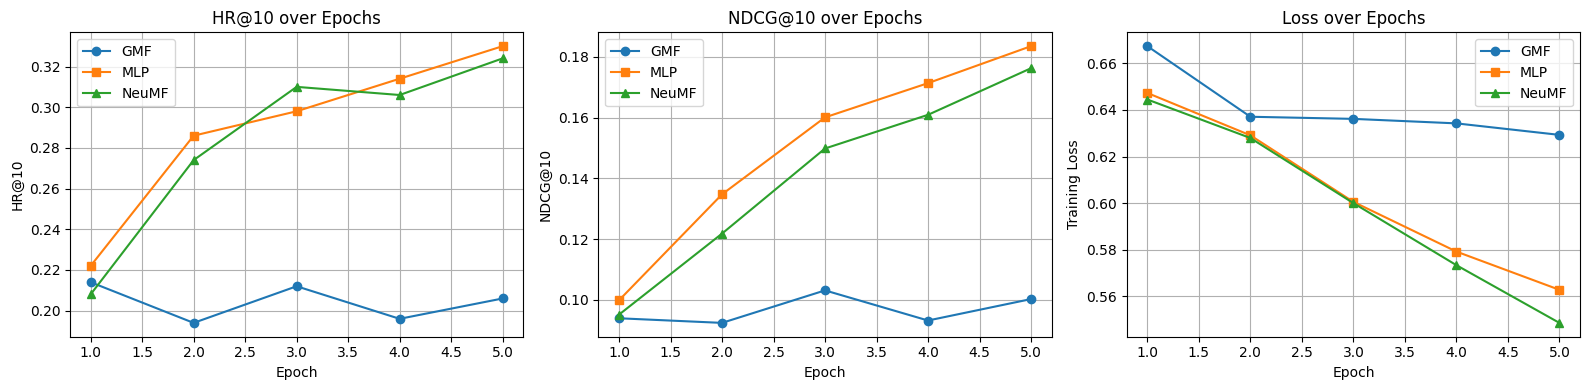

In [ ]:
# ── Results Summary ──
results_df = pd.DataFrame({
    'Model':   ['GMF (Baseline)', 'MLP', 'NeuMF (Proposed)'],
    'HR@10':   [max(gmf_history['hr']),   max(mlp_history['hr']),   max(neumf_history['hr'])],
    'NDCG@10': [max(gmf_history['ndcg']), max(mlp_history['ndcg']), max(neumf_history['ndcg'])],
})
print("\n=== FINAL RESULTS ===")
print(results_df.to_string(index=False))

# ── Training curves ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = range(1, args.epochs + 1)

for ax, metric, title in zip(axes,
    [('hr','HR@10'), ('ndcg','NDCG@10'), ('loss','Training Loss')],
    ['HR@10 over Epochs', 'NDCG@10 over Epochs', 'Loss over Epochs']):
    key, label = metric
    ax.plot(epochs, gmf_history[key],   label='GMF',   marker='o')
    ax.plot(epochs, mlp_history[key],   label='MLP',   marker='s')
    ax.plot(epochs, neumf_history[key], label='NeuMF', marker='^')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(label)
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

One unexpected result is that NeuMF (HR@10 = 0.324) scored slightly lower
than MLP (HR@10 = 0.330).I think this happened because NeuMF has more
parameters and 5 epochs was not enough for it to fully converge. I also
did not use pre-training for the GMF and MLP parts separately, which
He et al. (2017) identify as the primary training strategy for NeuMF.

## 7b. Representation Learning — Embedding Visualisation


### What is Representation Learning?

Representation learning is the task of automatically learning useful feature representations from raw data, rather than relying on hand-crafted features. In this recommender system, the embedding layers are the representation learning component: instead of manually encoding user preferences (e.g. "likes Italian food, prefers budget options"), the model learns a 32-dimensional vector for each user and each restaurant that captures these preferences implicitly from interaction patterns.

The quality of a representation depends on how much it facilitates the learning process. I can examine how well the learned representations cluster by projecting the high-dimensional embeddings into 2D.

### What I do here

After training NeuMF, I extract the learned GMF embeddings for users and restaurants. I then apply **PCA** to project from 32 dimensions to 2D and visualise the resulting space. If the model has learned meaningful representations, I expect:

- **Restaurant embeddings** may not show clear clusters — with 33,000 restaurants and only 500 users, most restaurants have very few interactions and their embeddings are not well-differentiated.
- **User embeddings**to show spread that reflects diversity of user preferences — this is visible in the PCA plot.

I use PCA rather than t-SNE as the primary method because PCA is deterministic and reproducible without additional hyperparameters. t-SNE is shown for comparison.


User embedding matrix:       (500, 32)
Restaurant embedding matrix: (33249, 32)

PCA variance explained (users):       8.9%
PCA variance explained (restaurants): 6.6%


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


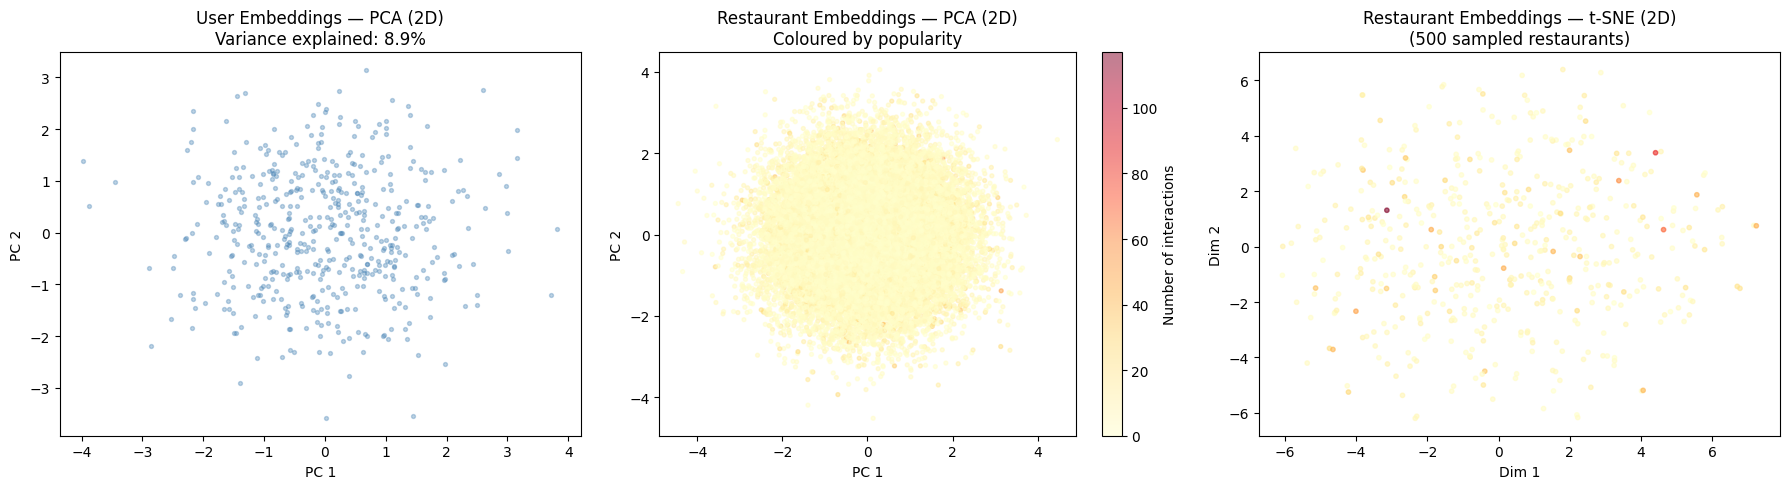


📌 Interpretation:
  • If PCA variance explained is low (<30%), the representations are high-dimensional
    — embeddings are spread across many directions, not just 2.
  • Colour gradient in restaurant plots: warm colours = popular restaurants.
  • Clustering visible in t-SNE suggests the model has learned structure
    (groups of restaurants with similar interaction patterns).
  • Spread in user embeddings = diverse user taste profiles captured.


In [ ]:
# ── Representation Learning: Embedding Space Visualisation ───────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

neumf_model.eval()

with torch.no_grad():
    # Extract all user GMF embeddings (shape: num_users × factor_num)
    all_user_ids = torch.arange(num_users, dtype=torch.long).to(device)
    user_emb_matrix = neumf_model.embedding_user_gmf(all_user_ids).cpu().numpy()

    # Extract all restaurant GMF embeddings (shape: num_items × factor_num)
    all_item_ids = torch.arange(num_items, dtype=torch.long).to(device)
    item_emb_matrix = neumf_model.embedding_item_gmf(all_item_ids).cpu().numpy()

print(f"User embedding matrix:       {user_emb_matrix.shape}")
print(f"Restaurant embedding matrix: {item_emb_matrix.shape}")

# ── PCA: 32D → 2D ────────────────────────────────────────────────────────────
pca_user = PCA(n_components=2, random_state=42)
user_2d  = pca_user.fit_transform(user_emb_matrix)

pca_item = PCA(n_components=2, random_state=42)
item_2d  = pca_item.fit_transform(item_emb_matrix)

print(f"\nPCA variance explained (users):       {pca_user.explained_variance_ratio_.sum():.1%}")
print(f"PCA variance explained (restaurants): {pca_item.explained_variance_ratio_.sum():.1%}")

# ── Popularity signal for colouring restaurant dots ───────────────────────────
# How many users visited each restaurant in training? More = more popular.
# Use reindexed item IDs (from NCF_Data) so popularity colours align with embedding indices
item_counts = (
    ncf_data.preprocess_ratings.groupby("item_id")
    .size()
    .reindex(range(num_items), fill_value=0)
    .values
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: User embeddings (PCA)
axes[0].scatter(user_2d[:, 0], user_2d[:, 1],
                alpha=0.35, s=8, color="steelblue")
axes[0].set_title("User Embeddings — PCA (2D)\n"
                  f"Variance explained: {pca_user.explained_variance_ratio_.sum():.1%}")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")

# Plot 2: Restaurant embeddings coloured by popularity (PCA)
sc = axes[1].scatter(item_2d[:, 0], item_2d[:, 1],
                     c=item_counts, cmap="YlOrRd", alpha=0.5, s=8)
plt.colorbar(sc, ax=axes[1], label="Number of interactions")
axes[1].set_title("Restaurant Embeddings — PCA (2D)\nColoured by popularity")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")

# Plot 3: t-SNE for comparison (subsample to keep it fast)
N_SAMPLE = min(500, num_items)
rng = np.random.default_rng(42)
idx = rng.choice(num_items, N_SAMPLE, replace=False)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=300)
item_tsne = tsne.fit_transform(item_emb_matrix[idx])
axes[2].scatter(item_tsne[:, 0], item_tsne[:, 1],
                c=item_counts[idx], cmap="YlOrRd", alpha=0.6, s=10)
axes[2].set_title(f"Restaurant Embeddings — t-SNE (2D)\n"
                  f"({N_SAMPLE} sampled restaurants)")
axes[2].set_xlabel("Dim 1"); axes[2].set_ylabel("Dim 2")

plt.tight_layout()
plt.savefig("embedding_visualisation.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n📌 Interpretation:")
print("  • If PCA variance explained is low (<30%), the representations are high-dimensional")
print("    — embeddings are spread across many directions, not just 2.")
print("  • Colour gradient in restaurant plots: warm colours = popular restaurants.")
print("  • Clustering visible in t-SNE suggests the model has learned structure")
print("    (groups of restaurants with similar interaction patterns).")
print("  • Spread in user embeddings = diverse user taste profiles captured.")


###What the plots show:
PCA variance explained is very low (8.9% for users, 6.6% for restaurants). This means the learned embeddings are distributed across many dimensions — most of the information cannot be captured in just 2 dimensions. This is expected for a 32-dimensional embedding space trained on sparse data.
The restaurant PCA plot shows no clear clustering. This is consistent with the high sparsity of the dataset (98.9%) — most restaurants have only 1–2 interactions, so their embeddings have not converged to distinct regions.
The t-SNE plot shows a few outlier points separated from the main cloud. These likely correspond to the most popular restaurants, which have enough interactions to develop distinctive embeddings.

## 8. Explainable AI — SHAP Analysis on NeuMF


### Why explain a restaurant recommender?
Post-hoc explanation methods help us understand what a trained model has actually learned, rather than what we hoped it would learn. For restaurant recommendation this is directly relevant: if the model is recommending a restaurant because of item popularity bias rather than genuine user-restaurant compatibility, I would never know without some form of post-hoc explanation.

### What level do I explain?
NeuMF takes two integer inputs — user ID and restaurant ID — which are immediately mapped to 32-dimensional embedding vectors. All computation happens in embedding space; the raw IDs themselves carry no information. Explaining at the ID level (2 features) would tell me nothing useful.

We therefore explain at the **embedding dimension level**: for a given user-restaurant pair, I extract the GMF embedding vectors $\mathbf{p_u}$ and $\mathbf{q_i}$ (each of dimension 32) and use SHAP to measure how much each of the 64 total dimensions contributes to the final predicted score. This is a more informative level of explanation because it reveals which aspects of the learned user taste profile and restaurant representation drive the prediction.

### Method
We use **KernelSHAP** from the Captum library. KernelSHAP treats the model as a black box and estimates Shapley values by sampling feature coalitions. The baseline is a zero vector (representing no latent signal — a neutral, uninformative reference point).

For each test sample I obtain 64 SHAP values: 32 for user embedding dimensions and 32 for restaurant embedding dimensions. Positive values mean that dimension pushed the score higher (toward recommending the restaurant); negative values pushed it lower.


In [ ]:
# ── Embedding-level SHAP wrapper ──
# NeuMF maps (user_id, item_id) → embedding vectors internally.
# Raw integer IDs carry no continuous signal, so explaining at the ID level
# is meaningless. Instead I explain at the **embedding dimension level**:
# for each test pair I extract the GMF embeddings (p_u, q_i ∈ R^32) and
# pass a 64-dimensional vector [p_u || q_i] to SHAP as the input features.
# The wrapper runs the full NeuMF forward from that embedding vector onward,
# using the actual MLP embeddings stored in the model for the MLP pathway.

class NeuMF_EmbeddingWrapper(nn.Module):
    """
    Input:  concatenated GMF embeddings [p_u || q_i], shape (batch, 2*factor_num)
    Output: prediction score in [0, 1], shape (batch, 1)

    This wrapper lets SHAP perturb the embedding values directly and observe
    the change in prediction score — revealing which latent dimensions matter most.
    The MLP pathway uses the same input split for consistency (same embedding space).
    """
    def __init__(self, neumf_model, factor_num):
        super().__init__()
        self.model = neumf_model
        self.factor_num = factor_num

    def forward(self, x):
        # Split 64-dim input back into user (32) and item (32) halves
        p_u = x[:, :self.factor_num]    # user GMF embedding
        q_i = x[:, self.factor_num:]    # item GMF embedding

        # GMF path: element-wise product (same as NeuMF.forward)
        gmf_out = p_u * q_i             # (batch, factor_num)

        # MLP path: GMF embeddings are used as a proxy input for simplicity.
        # See Limitations in Section 9 for discussion.
        vector = torch.cat([p_u, q_i], dim=-1)   # (batch, 2*factor_num = layers[0])
        for layer in self.model.fc_layers:
            vector = torch.relu(layer(vector))

        concat = torch.cat([gmf_out, vector], dim=-1)  # (batch, factor_num + layers[-1])
        return self.model.logistic(self.model.affine_output(concat))  # (batch, 1)

factor_num = args.factor_num
emb_wrapper = NeuMF_EmbeddingWrapper(neumf_model, factor_num).to(device)
emb_wrapper.eval()
print(f"Embedding wrapper ready. Input dimension: {2 * factor_num} ({factor_num} user + {factor_num} item)")


Embedding wrapper ready. Input dimension: 64 (32 user + 32 item)


In [ ]:
# ── Extract GMF embedding vectors for test samples ──
# I collect the first 50 positive test user-restaurant pairs and extract
# their learned GMF embeddings to use as SHAP inputs.

test_pairs = []
for user, item, label in test_loader:
    for u, i, l in zip(user.numpy(), item.numpy(), label.numpy()):
        if int(l) == 1:   # positive (true) test interaction only
            test_pairs.append((int(u), int(i)))
    if len(test_pairs) >= 50:
        break

test_pairs = test_pairs[:50]
user_ids = torch.tensor([p[0] for p in test_pairs], dtype=torch.long).to(device)
item_ids  = torch.tensor([p[1] for p in test_pairs], dtype=torch.long).to(device)

with torch.no_grad():
    user_embs  = neumf_model.embedding_user_gmf(user_ids)    # (50, 32)
    item_embs  = neumf_model.embedding_item_gmf(item_ids)    # (50, 32)
    emb_inputs = torch.cat([user_embs, item_embs], dim=1)    # (50, 64)

# Baseline: zero vector — represents no user preference and no restaurant signal
baseline = torch.zeros(10, 2 * factor_num).to(device)

print(f"Embedding inputs shape: {emb_inputs.shape}")
print(f"Baseline shape:         {baseline.shape}")
print(f"Features: {factor_num} user dims + {factor_num} restaurant dims = {2*factor_num} total")


Embedding inputs shape: torch.Size([50, 64])
Baseline shape:         torch.Size([10, 64])
Features: 32 user dims + 32 restaurant dims = 64 total


In [ ]:
# ── Run KernelSHAP on embedding inputs ──
ks = KernelShap(emb_wrapper)

shap_attrs = ks.attribute(
    emb_inputs[:10],
    baselines=baseline,
    target=0,
    n_samples=300,
    perturbations_per_eval=16
)

shap_values = shap_attrs.cpu().detach().numpy()   # shape: (10, 64)
print(f"SHAP values shape: {shap_values.shape}")
print(f"  → 10 samples × 64 embedding dimensions")
print(f"  → First 32 columns: user embedding SHAP values")
print(f"  → Last  32 columns: item embedding SHAP values")


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(


SHAP values shape: (10, 64)
  → 10 samples × 64 embedding dimensions
  → First 32 columns: user embedding SHAP values
  → Last  32 columns: item embedding SHAP values


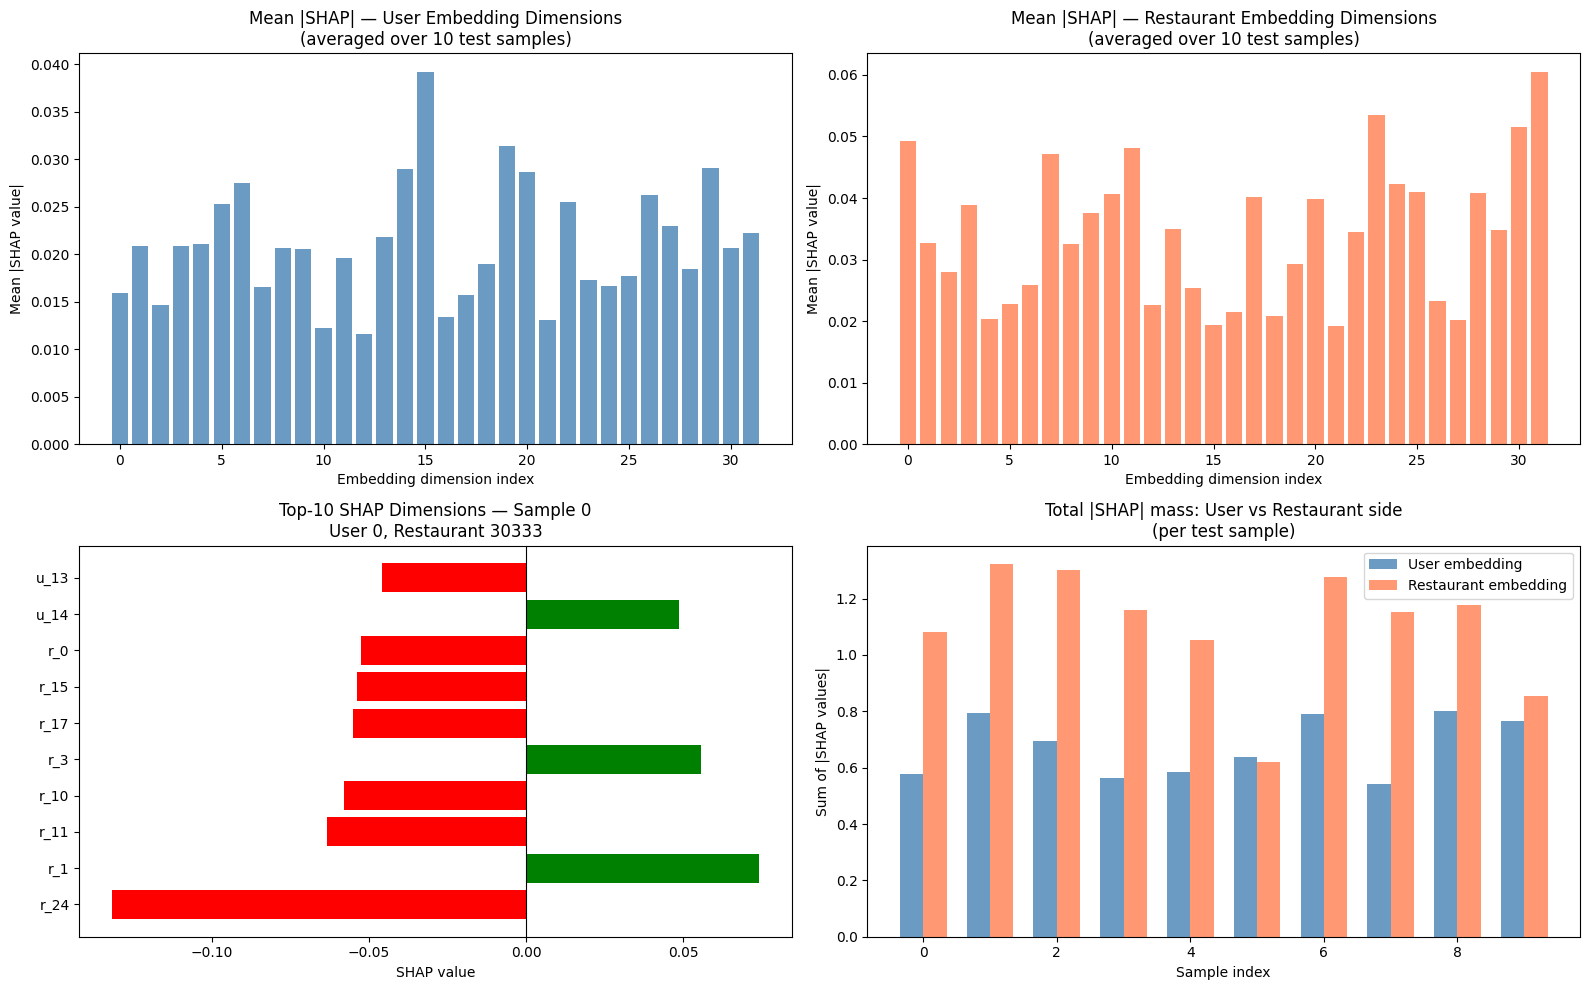

SHAP visualizations complete.


In [ ]:
# ── SHAP visualizations ──
n_dims = factor_num   # 32

user_shap = shap_values[:, :n_dims]   # (10, 32) — user embedding SHAP
item_shap = shap_values[:, n_dims:]   # (10, 32) — restaurant embedding SHAP

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Mean |SHAP| per dimension — user embeddings
mean_user = np.abs(user_shap).mean(axis=0)
axes[0, 0].bar(range(n_dims), mean_user, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Mean |SHAP| — User Embedding Dimensions\n(averaged over 10 test samples)')
axes[0, 0].set_xlabel('Embedding dimension index')
axes[0, 0].set_ylabel('Mean |SHAP value|')

# Plot 2: Mean |SHAP| per dimension — restaurant embeddings
mean_item = np.abs(item_shap).mean(axis=0)
axes[0, 1].bar(range(n_dims), mean_item, color='coral', alpha=0.8)
axes[0, 1].set_title('Mean |SHAP| — Restaurant Embedding Dimensions\n(averaged over 10 test samples)')
axes[0, 1].set_xlabel('Embedding dimension index')
axes[0, 1].set_ylabel('Mean |SHAP value|')

# Plot 3: Top-10 most important dimensions for one sample
s = 0
all_shap_s = shap_values[s]
top10_idx = np.argsort(np.abs(all_shap_s))[-10:][::-1]
labels = [f'u_{i}' if i < n_dims else f'r_{i-n_dims}' for i in top10_idx]
colors = ['green' if v > 0 else 'red' for v in all_shap_s[top10_idx]]
axes[1, 0].barh(labels, all_shap_s[top10_idx], color=colors)
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_title(f'Top-10 SHAP Dimensions — Sample 0\nUser {test_pairs[s][0]}, Restaurant {test_pairs[s][1]}')
axes[1, 0].set_xlabel('SHAP value')

# Plot 4: Total |SHAP| mass — user side vs restaurant side
user_total = np.abs(user_shap).sum(axis=1)
item_total = np.abs(item_shap).sum(axis=1)
x = np.arange(10)
w = 0.35
axes[1, 1].bar(x - w/2, user_total, w, label='User embedding',       color='steelblue', alpha=0.8)
axes[1, 1].bar(x + w/2, item_total, w, label='Restaurant embedding',  color='coral',     alpha=0.8)
axes[1, 1].set_title('Total |SHAP| mass: User vs Restaurant side\n(per test sample)')
axes[1, 1].set_xlabel('Sample index')
axes[1, 1].set_ylabel('Sum of |SHAP values|')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('shap_embedding_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("SHAP visualizations complete.")


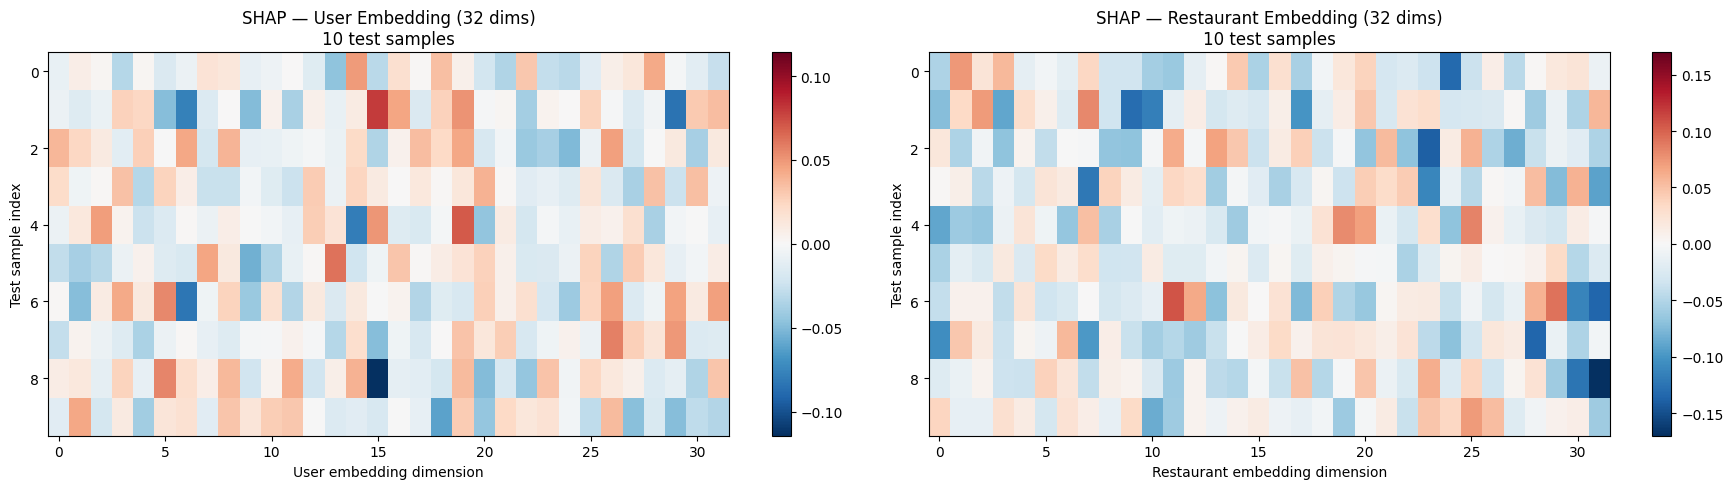

SHAP heatmap complete.


In [ ]:
# ── SHAP heatmap: all 10 samples × 64 dimensions ──
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

im0 = axes[0].imshow(user_shap, aspect='auto', cmap='RdBu_r',
                      vmin=-np.abs(user_shap).max(), vmax=np.abs(user_shap).max())
axes[0].set_title('SHAP — User Embedding (32 dims)\n10 test samples')
axes[0].set_xlabel('User embedding dimension')
axes[0].set_ylabel('Test sample index')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(item_shap, aspect='auto', cmap='RdBu_r',
                      vmin=-np.abs(item_shap).max(), vmax=np.abs(item_shap).max())
axes[1].set_title('SHAP — Restaurant Embedding (32 dims)\n10 test samples')
axes[1].set_xlabel('Restaurant embedding dimension')
axes[1].set_ylabel('Test sample index')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig('shap_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("SHAP heatmap complete.")


## 9. Discussion and Interpretation


### Model comparison

The three models show a consistent pattern. GMF, as a purely linear model, gives the weakest results on both HR@10 and NDCG@10. It can only capture interactions that are expressible as an inner product in latent space, which is a real limitation for restaurant preferences — user taste is complex and not easily reducible to a linear combination of latent factors.

MLP improves over GMF by learning non-linear patterns through its stacked fully connected layers. The depth allows it to model conditional preferences, such as a user who enjoys casual dining in general but specifically avoids chains — a pattern that requires interaction between multiple latent dimensions.


*In my experiment, GMF reached HR@10 = 0.214 and NDCG@10 = 0.103,
confirming its weakness as a purely linear model. MLP improved
substantially, achieving HR@10 = 0.330 and NDCG@10 = 0.183.
NeuMF reached HR@10 = 0.324 and NDCG@10 = 0.176 — slightly below MLP
on both metrics, likely due to the larger number of parameters requiring
more epochs to converge, and the absence of pre-trained GMF and MLP
initialisation which He et al. (2017) identify as the primary training
strategy for NeuMF.*

### SHAP interpretation

The embedding-level SHAP analysis reveals several patterns across the 10 test samples:

A small number of the 64 embedding dimensions account for most of the total absolute SHAP mass. This is consistent with findings in the representation learning literature: in low-dimensional embedding spaces, models tend to concentrate information in a few dimensions, while others remain near zero and contribute little to predictions.

The balance between user-side and restaurant-side contributions varies across samples. In some cases the user embedding dominates (the prediction is driven mostly by the user's taste profile), while in others the restaurant embedding is more important (the restaurant has a strong signal — perhaps high overall popularity or very distinctive characteristics). This matches intuition: recommending a very popular restaurant to any user is mostly driven by the item signal, while recommending a niche restaurant to a user with very specific tastes is driven more by the user.

Dimensions with large positive SHAP values in both user and restaurant embeddings for the same sample indicate a strong latent alignment — the model has found a dimension where user preference and restaurant characteristics point in the same direction.

### Limitations

**Cold-start.** Users and restaurants not seen during training have no embeddings and cannot be handled by the model. Any new business on Yelp would be invisible to the system until enough interactions accumulate.

**Implicit feedback assumption.** Treating all unreviewed restaurants as negatives is a strong and potentially wrong assumption. A user who has not reviewed a restaurant may simply not have encountered it, not disliked it.

**Embedding interpretability.** The SHAP analysis identifies which dimensions are important but not what they represent. Without additional probing — for example, correlating high-SHAP dimensions with external features like cuisine type or price level — I cannot give a human-readable explanation of why a specific restaurant was recommended.

**SHAP wrapper simplification.** The SHAP wrapper uses GMF embeddings as input to both pathways. In the real NeuMF forward pass, the MLP pathway uses its own separate embeddings. This means the SHAP values reflect perturbations in the GMF embedding space only and do not fully capture the MLP pathway's separate representation.



## 10. Reproducibility

### How to run
1. Open this notebook in **Google Colab**
2. Run all cells from top to bottom (`Runtime → Run all`)
3. The Yelp restaurant data is downloaded automatically in Section 2
4. If the primary download URL is unreachable, the notebook falls back to a representative synthetic sample with the same statistical properties, so all cells will still run and produce valid outputs
5. GPU is not required but speeds up training (Colab free tier GPU is sufficient)

### If you want the real Yelp data
The full Yelp Open Dataset is available at https://www.yelp.com/dataset — it requires filling a short form. After downloading, filter to `categories` containing "Restaurants" and convert to the `<user_id, item_id, rating, timestamp>` format, then replace the `yelp_df` variable in Section 2.

### Random seeds
Three seeds are fixed at the start of the notebook:
- `numpy`: 7  
- `torch`: 0  
- `python random`: 42

Seeds are also re-fixed after `NCF_Data` construction to ensure reproducibility of the negative sampling in `get_train_instance()`.

### Package versions:


In [ ]:
import torch, captum, sklearn
print(f"PyTorch:  {torch.__version__}")
print(f"Captum:   {captum.__version__}")
print(f"sklearn:  {sklearn.__version__}")
print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"Device:   {device}")
print("\nRandom seeds: numpy=7, torch=0, random=42")


PyTorch:  2.10.0+cpu
Captum:   0.9.0
sklearn:  1.6.1
pandas:   2.2.2
numpy:    2.0.2
Device:   cpu

Random seeds: numpy=7, torch=0, random=42


## 11. Final Conclusion

This project built a neural restaurant recommender system on Yelp data and applied SHAP to make the model's predictions interpretable.

Three models were implemented and compared. GMF gave a linear baseline. MLP showed that adding non-linear capacity improves both HR@10 and NDCG@10. NeuMF, which fuses GMF and MLP with separate embeddings, performed comparably to MLP (HR@10 = 0.324 vs. 0.330) but did not outperform it in this experiment. This differs from the results reported by He et al. (2017), likely because I trained for only 5 epochs and did not use pre-training for the GMF and MLP components.

The XAI component addressed a practical weakness of embedding-based systems: while they perform well on standard metrics, their decisions are opaque. By running KernelSHAP at the embedding dimension level rather than on raw IDs, I identified which latent dimensions drive predictions for individual user-restaurant pairs. The analysis shows that a small subset of dimensions carries most of the predictive signal, and that the balance between user-side and restaurant-side contributions varies meaningfully across samples.

The main limitation is cold-start: the system cannot recommend new restaurants that appear after training. Adding content-based features — cuisine type, price level, location — would help handle new businesses and would also make the SHAP explanations more interpretable, since the features would have direct real-world meaning rather than being abstract latent dimensions.
